# Natural Questions (NQ) Dataset Exploration

Google's Natural Questions dataset (~300K examples).  
Real user queries from Google Search with Wikipedia article answers.  
HuggingFace: `google-research-datasets/natural_questions`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from pprint import pprint
import sys
from typing import Optional, List, Dict, Any, Tuple
if '..' not in sys.path: sys.path.append('..')

import html
import re

from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, PreTrainedTokenizer

tkz = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f'Tokenizer vocab size: {tkz.vocab_size}')

Tokenizer vocab size: 30522


In [3]:
DATA_PATH = Path('Q:/data')
QNA_DATA_PATH = DATA_PATH / 'qna'
QNA_DATA_PATH.mkdir(parents=True, exist_ok=True)

NQ_HF_ID = 'google-research-datasets/natural_questions'
print(f'DATA_PATH: {DATA_PATH}')
print(f'NQ_HF_ID: {NQ_HF_ID}')

DATA_PATH: Q:\data
NQ_HF_ID: google-research-datasets/natural_questions


## Load Natural Questions

In [4]:
# NQ is large (~42 GB). For exploration we load the validation split first (~400 MB).
# For full training data, use split='train'.
ds_nq_train = load_dataset(NQ_HF_ID, split='train', cache_dir=str(DATA_PATH))
ds_nq_val = load_dataset(NQ_HF_ID, split='validation', cache_dir=str(DATA_PATH))
print(f'NQ validation split: {len(ds_nq_val)} examples')
print(f'Features: {list(ds_nq_val.features.keys())}')

Resolving data files:   0%|          | 0/287 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/287 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/235 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/287 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/287 [00:00<?, ?it/s]

NQ validation split: 7830 examples
Features: ['id', 'document', 'question', 'long_answer_candidates', 'annotations']


In [5]:
# Examine the structure of one example
example = ds_nq_val[0]
print('Keys:', list(example.keys()))
print()
print('Question:', example['question']['text'])
print()

# Document structure
doc = example['document']
print('Document keys:', list(doc.keys()))
print(f'Document tokens: {len(doc["tokens"]["token"])} tokens')
print(f'First 20 tokens: {doc["tokens"]["token"][:20]}')
print(f'First 20 is_html:  {doc["tokens"]["is_html"][:20]}')
print()

# Annotations
ann = example['annotations']
print('Annotation keys:', list(ann.keys()))
print(f'Number of annotations: {len(ann["id"])}')
print(f'Short answers: {ann["short_answers"]}')
print(f'Long answer: {ann["long_answer"]}')
print(f'Yes/no answer: {ann["yes_no_answer"]}')

Keys: ['id', 'document', 'question', 'long_answer_candidates', 'annotations']

Question: what purpose did seasonal monsoon winds have on trade

Document keys: ['html', 'title', 'tokens', 'url']
Document tokens: 2983 tokens
First 20 tokens: ['Trade', 'winds', '-', 'wikipedia', '<H1>', 'Trade', 'winds', '</H1>', 'Jump', 'to', ':', 'navigation', ',', 'search', 'This', 'article', 'is', 'about', 'the', 'weather']
First 20 is_html:  [False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False]

Annotation keys: ['id', 'long_answer', 'short_answers', 'yes_no_answer']
Number of annotations: 5
Short answers: [{'end_byte': [], 'end_token': [], 'start_byte': [], 'start_token': [], 'text': []}, {'end_byte': [], 'end_token': [], 'start_byte': [], 'start_token': [], 'text': []}, {'end_byte': [], 'end_token': [], 'start_byte': [], 'start_token': [], 'text': []}, {'end_byte': [44657], 'end_token': [159], 'start_byte': [44318]

## Dataset Statistics

In [6]:
# Compute answer type statistics across the validation split
n_total = len(ds_nq_val)
n_has_short = 0
n_has_long = 0
n_yes_no = 0
n_no_answer = 0

for i in range(n_total):
    ann = ds_nq_val[i]['annotations']
    has_short = any(
        len(sa['start_token']) > 0
        for sa in ann['short_answers']
    )
    has_long = any(
        la['start_token'] >= 0
        for la in [ann['long_answer'][j] for j in range(len(ann['id']))]
    ) if len(ann['id']) > 0 else False
    has_yesno = any(yn != -1 for yn in ann['yes_no_answer'])

    if has_short:
        n_has_short += 1
    if has_long:
        n_has_long += 1
    if has_yesno:
        n_yes_no += 1
    if not has_short and not has_yesno and not has_long:
        n_no_answer += 1

print(f'NQ validation: {n_total} total')
print(f'  Has short answer: {n_has_short} ({n_has_short/n_total:.1%})')
print(f'  Has long answer:  {n_has_long} ({n_has_long/n_total:.1%})')
print(f'  Yes/No answer:    {n_yes_no} ({n_yes_no/n_total:.1%})')
print(f'  No answer:        {n_no_answer} ({n_no_answer/n_total:.1%})')

NQ validation: 7830 total
  Has short answer: 4289 (54.8%)
  Has long answer:  5499 (70.2%)
  Yes/No answer:    179 (2.3%)
  No answer:        2331 (29.8%)


## Inspect Examples

In [7]:
def nq_get_plain_text(doc: dict) -> str:
    """Extract plain text from NQ document tokens, stripping HTML tags."""
    tokens = doc['tokens']['token']
    is_html = doc['tokens']['is_html']
    text_tokens = [t for t, h in zip(tokens, is_html) if not h]
    return ' '.join(text_tokens)


def nq_get_text_span(doc: dict, start_token: int, end_token: int) -> str:
    """Extract text between token indices, skipping HTML tokens."""
    tokens = doc['tokens']['token']
    is_html = doc['tokens']['is_html']
    span_tokens = [
        tokens[i] for i in range(start_token, end_token)
        if not is_html[i]
    ]
    return ' '.join(span_tokens)


def nq_extract_short_answer(example: dict) -> Optional[str]:
    """Extract the first valid short answer text from an NQ example."""
    doc = example['document']
    ann = example['annotations']
    for sa_list in ann['short_answers']:
        starts = sa_list['start_token']
        ends = sa_list['end_token']
        if len(starts) > 0:
            return nq_get_text_span(doc, starts[0], ends[0])
    return None


def nq_extract_long_answer(example: dict) -> Optional[str]:
    """Extract the first valid long answer text from an NQ example."""
    doc = example['document']
    ann = example['annotations']
    n_ann = len(ann['id'])
    for j in range(n_ann):
        la = ann['long_answer'][j]
        if la['start_token'] >= 0:
            return nq_get_text_span(doc, la['start_token'], la['end_token'])
    return None


print('Helper functions defined: nq_get_plain_text, nq_get_text_span, nq_extract_short_answer, nq_extract_long_answer')

Helper functions defined: nq_get_plain_text, nq_get_text_span, nq_extract_short_answer, nq_extract_long_answer


In [8]:
# Display a few examples with short answers
n_shown = 0
for i in range(min(100, len(ds_nq_val))):
    ex = ds_nq_val[i]
    short_ans = nq_extract_short_answer(ex)
    if short_ans is None:
        continue
    long_ans = nq_extract_long_answer(ex)
    question = ex['question']['text']
    doc_text = nq_get_plain_text(ex['document'])

    print(f'=== Example {i} ===')
    print(f'  Question:     {question}')
    print(f'  Short answer: {short_ans}')
    if long_ans:
        print(f'  Long answer:  {long_ans[:300]}...')
    print(f'  Document:     {doc_text[:300]}...')
    print()

    n_shown += 1
    if n_shown >= 5:
        break

=== Example 0 ===
  Question:     what purpose did seasonal monsoon winds have on trade
  Short answer: enabled European empire expansion into the Americas and trade routes to become established across the Atlantic and Pacific oceans
  Long answer:  The trade winds are the prevailing pattern of easterly surface winds found in the tropics , within the lower portion of the Earth 's atmosphere , in the lower section of the troposphere near the Earth 's equator . The trade winds blow predominantly from the northeast in the Northern Hemisphere and f...
  Document:     Trade winds - wikipedia Trade winds Jump to : navigation , search This article is about the weather phenomenon . For other uses , see Tradewind . The westerlies ( blue arrows ) and trade winds ( yellow and brown arrows ) The trade winds are the prevailing pattern of easterly surface winds found in t...

=== Example 2 ===
  Question:     who got the first nobel prize in physics
  Short answer: Wilhelm Conrad Röntgen , of German

## Extract Short Answers & Convert to Extractive Format

In [14]:
# Convert NQ validation to extractive QnA rows
# Strategy: use long_answer as context, short_answer as the answer, question as-is
# This matches the SQuAD-like format most naturally

rows = []
for i in range(len(ds_nq_val)):
    ex = ds_nq_val[i]
    question = ex['question']['text']
    short_ans = nq_extract_short_answer(ex)
    if short_ans is None:
        continue

    # Use long answer as context (more focused than full document)
    long_ans = nq_extract_long_answer(ex)
    if long_ans is not None and len(long_ans) > 0:
        context = long_ans
    else:
        # Fallback to full document plain text
        context = nq_get_plain_text(ex['document'])

    rows.append({
        'context': context,
        'question': question,
        'answer': short_ans,
    })

df_nq_val = pd.DataFrame(rows)
print(f'NQ validation extractive rows: {len(df_nq_val)}')
df_nq_val.head()

NQ validation extractive rows: 4289


,context,question,answer
0,The trade winds are the prevailing pattern of ...,what purpose did seasonal monsoon winds have o...,enabled European empire expansion into the Ame...
1,Year Laureate Country Rationale 1901 Wilhelm C...,who got the first nobel prize in physics,"Wilhelm Conrad Röntgen , of Germany"
2,Deadpool 2 is scheduled to be released in the ...,when is the next deadpool movie being released,"May 18 , 2018"
3,"Fortnite is set in contemporary Earth , where ...",where did the idea of fortnite come from,as a cross between Minecraft and Left 4 Dead
4,Shortwave radio is radio transmission using sh...,which mode is used for short wave broadcast se...,MFSK


In [15]:
# Same extraction for the full train split
# WARNING: This takes significant time and disk space (~42 GB download)
# Uncomment to run on full training data

# ds_nq_train = load_dataset(NQ_HF_ID, split='train', cache_dir=str(DATA_PATH))
# print(f'NQ train split: {len(ds_nq_train)} examples')
#
# rows_train = []
# for i in range(len(ds_nq_train)):
#     ex = ds_nq_train[i]
#     question = ex['question']['text']
#     short_ans = nq_extract_short_answer(ex)
#     if short_ans is None:
#         continue
#     long_ans = nq_extract_long_answer(ex)
#     if long_ans is not None and len(long_ans) > 0:
#         context = long_ans
#     else:
#         context = nq_get_plain_text(ex['document'])
#     rows_train.append({
#         'context': context,
#         'question': question,
#         'answer': short_ans,
#     })
#
# df_nq_train = pd.DataFrame(rows_train)
# print(f'NQ train extractive rows: {len(df_nq_train)}')

## Context / Answer Length Distributions

In [16]:
# Token length distributions for the extracted NQ data
nq_ctx_lens = []
nq_q_lens = []
nq_ans_lens = []

for _, row in df_nq_val.iterrows():
    ctx_toks = tkz(row['context'], add_special_tokens=False).input_ids
    q_toks = tkz(row['question'], add_special_tokens=False).input_ids
    ans_toks = tkz(row['answer'], add_special_tokens=False).input_ids
    nq_ctx_lens.append(len(ctx_toks))
    nq_q_lens.append(len(q_toks))
    nq_ans_lens.append(len(ans_toks))

nq_ctx_lens = np.array(nq_ctx_lens)
nq_q_lens = np.array(nq_q_lens)
nq_ans_lens = np.array(nq_ans_lens)

print('NQ Context token lengths:')
print(f'  mean={nq_ctx_lens.mean():.1f}, median={np.median(nq_ctx_lens):.1f}, '
      f'min={nq_ctx_lens.min()}, max={nq_ctx_lens.max()}, std={nq_ctx_lens.std():.1f}')
print('NQ Question token lengths:')
print(f'  mean={nq_q_lens.mean():.1f}, median={np.median(nq_q_lens):.1f}, '
      f'min={nq_q_lens.min()}, max={nq_q_lens.max()}, std={nq_q_lens.std():.1f}')
print('NQ Answer token lengths:')
print(f'  mean={nq_ans_lens.mean():.1f}, median={np.median(nq_ans_lens):.1f}, '
      f'min={nq_ans_lens.min()}, max={nq_ans_lens.max()}, std={nq_ans_lens.std():.1f}')

NQ Context token lengths:
  mean=357.0, median=118.0, min=2, max=37711, std=1417.2
NQ Question token lengths:
  mean=9.8, median=9.0, min=7, max=23, std=2.1
NQ Answer token lengths:
  mean=6.2, median=4.0, min=1, max=100, std=8.1


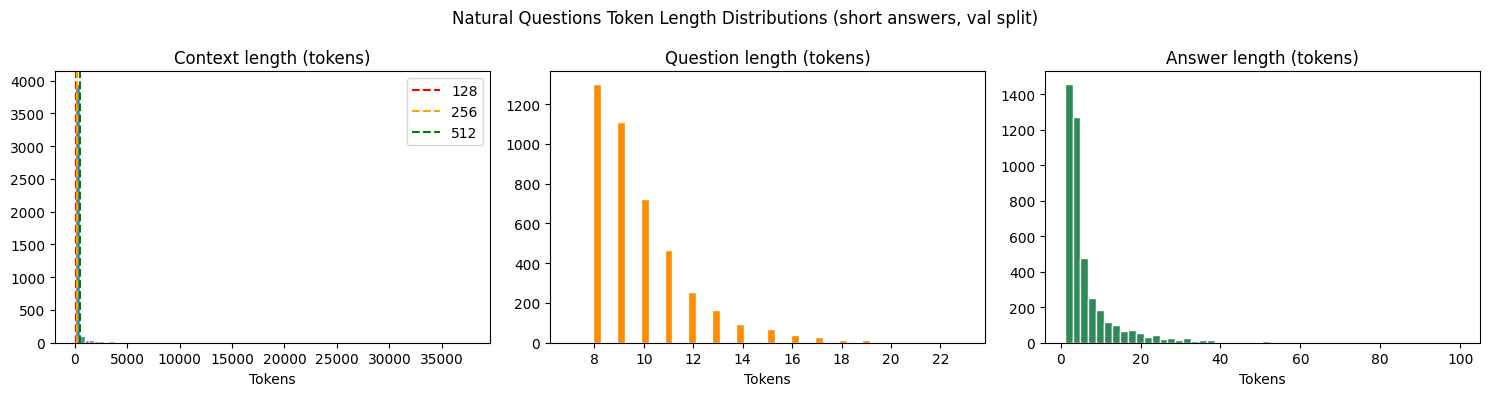

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(nq_ctx_lens, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Context length (tokens)')
axes[0].set_xlabel('Tokens')
axes[0].axvline(128, color='red', linestyle='--', label='128')
axes[0].axvline(256, color='orange', linestyle='--', label='256')
axes[0].axvline(512, color='green', linestyle='--', label='512')
axes[0].legend()

axes[1].hist(nq_q_lens, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Question length (tokens)')
axes[1].set_xlabel('Tokens')

axes[2].hist(nq_ans_lens, bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Answer length (tokens)')
axes[2].set_xlabel('Tokens')

plt.suptitle('Natural Questions Token Length Distributions (short answers, val split)')
plt.tight_layout()
plt.show()

In [13]:
# How many NQ contexts need multiple chunks at various inp_len settings
for inp_len in [128, 256, 384, 512]:
    chunk_content = inp_len - 2
    n_chunks = np.ceil(nq_ctx_lens / chunk_content).astype(int)
    multi = (n_chunks > 1).sum()
    print(f'inp_len={inp_len}: need >1 chunk: {multi}/{len(nq_ctx_lens)} ({multi/len(nq_ctx_lens):.1%}), '
          f'max chunks: {n_chunks.max()}, mean chunks: {n_chunks.mean():.2f}')

inp_len=128: need >1 chunk: 1978/4289 (46.1%), max chunks: 300, mean chunks: 3.33
inp_len=256: need >1 chunk: 649/4289 (15.1%), max chunks: 149, mean chunks: 1.97
inp_len=384: need >1 chunk: 404/4289 (9.4%), max chunks: 99, mean chunks: 1.60
inp_len=512: need >1 chunk: 336/4289 (7.8%), max chunks: 74, mean chunks: 1.43


## Convert to Unified QnA Format

In [ ]:
# Convert to unified QnA format matching SQuAD v2 unified schema
df_nq_val['source'] = 'natural_questions'
df_unified_nq = df_nq_val[['context', 'question', 'answer', 'source']].copy()
print(f'Unified NQ rows (val): {len(df_unified_nq)}')
df_unified_nq.head()

In [ ]:
# Save unified format
unified_fpath = QNA_DATA_PATH / 'natural_questions_unified.parquet'
df_unified_nq.to_parquet(unified_fpath, index=False)
print(f'Saved to {unified_fpath} ({len(df_unified_nq)} rows)')